# Applying Fitts' law to Wikispeedia

In [56]:
from DataLoader import DataLoader
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats

tqdm.pandas()

In [42]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")
dataloader.paths

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
0,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,African_slave_trade
1,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,African_slave_trade
2,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,Greece
3,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,John_F._Kennedy
4,5295bca242be81fe,1372890414,110,"[14th_century, Europe, North_America, United_S...",NaN,John_F._Kennedy
...,...,...,...,...,...,...
51312,15a13a1d66ef5456,1349231015,66,"[Yagan, Ancient_Egypt, Civilization]",NaN,Civilization
51313,2ef7ac844cefda58,1300254138,165,"[Yagan, Folklore, Brothers_Grimm, Folklore, 19...",3.0,Fiction
51314,12863abb7887f890,1385095372,228,"[Yagan, Australia, England, France, United_Sta...",NaN,U.S._Open_%28tennis%29
51315,19f8284371753362,1298792567,56,"[Yarralumla%2C_Australian_Capital_Territory, A...",1.0,Abraham_Lincoln


In [64]:
dataloader.paths.sort_values(by="durationInSec")[:50000]

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
9588,5590014e126275b4,1225696755,0,[Moon],NaN,Moon
34301,43f864c75b2571b5,1350587407,0,[American_Samoa],NaN,American_Samoa
50465,43f864c75b2571b5,1350587414,0,[William_and_Mary],NaN,William_and_Mary
38926,43f864c75b2571b5,1350587383,0,[Florence_Nightingale],NaN,Florence_Nightingale
5856,43f864c75b2571b5,1350587401,0,[Lesotho],NaN,Lesotho
...,...,...,...,...,...,...
20287,038fa48f0d6caadf,1301670739,555,"[Pyramid, France, Portuguese_language, Brazil,...",4.0,Bean
1532,581af58d2fafd5d5,1353011517,555,"[Batman, Scotland, Ireland, United_Kingdom, Wo...",NaN,The_Holocaust
34130,745767f253f72034,1230736027,555,"[Al_Jazeera, Afghanistan, India, Indian_indepe...",NaN,Indian_independence_movement
47827,18f04531320cff22,1255905866,555,"[Tank, World_War_II, United_Kingdom, Market, M...",5.0,Asparagus


## Embed article titles as distance metric

In [43]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

In [44]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [45]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

In [46]:
dataloader.pagerank

%C3%81ed%C3%A1n_mac_Gabr%C3%A1in    0.000033
Columba                             0.000121
D%C3%A1l_Riata                      0.000106
Great_Britain                       0.001506
Ireland                             0.001900
                                      ...   
Yellowhammer                        0.000033
Yotsuya_Kaidan                      0.000033
You%27re_Still_the_One              0.000033
Yungay%2C_Peru                      0.000033
Zara_Yaqob                          0.000033
Name: PageRank, Length: 4592, dtype: float64

In [111]:
def analyze_path(p):
    try:
        path = p['path']
        if len(path) < 2:
            # ignore non-games
            return None
        target_pagerank = dataloader.pagerank[path[-1]] # use pagerank as size
        distance = -float(model.similarity(embeddings[path[0]], embeddings[path[-1]]))
        difficulty = math.log2(distance / target_pagerank)
        time = p['durationInSec']
        if time > 600:
            # ignore outliers
            return None
        return pd.Series([time, difficulty, distance, target_pagerank])
    except KeyError:
        return None


df = dataloader.paths.progress_apply(analyze_path, axis=1).dropna()
df.columns = ["Time", "ID", "Distance", "PageRank"]
df

100%|██████████| 51317/51317 [00:04<00:00, 11452.52it/s]


,Time,ID,Distance,PageRank
0,88.0,14.796754,1.175529,0.000041
1,138.0,14.796754,1.175529,0.000041
2,37.0,9.413280,1.134654,0.001664
3,175.0,11.872130,1.212270,0.000323
4,110.0,11.872130,1.212270,0.000323
...,...,...,...,...
51312,66.0,11.090710,1.251362,0.000574
51313,165.0,12.775375,1.241741,0.000177
51314,228.0,13.074862,1.297113,0.000150
51315,56.0,11.656392,1.326535,0.000411


In [121]:
X = df["ID"]
y = df["Time"]

In [122]:
slope, intercept, rval, pval, stderr = stats.linregress(X, y)
print(f"rval = {rval}, y = {slope} x + {intercept}")

rval = 0.2756895570755298, y = 18.480268608113562 x + -93.67088179524512


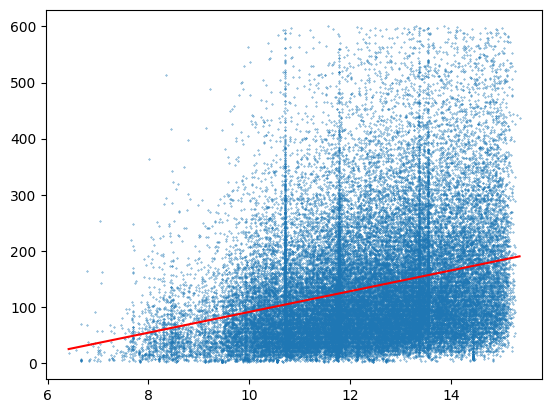

In [132]:
plt.scatter(X, y, s=0.1)

xs = np.linspace(min(X), max(X))
ys = slope*xs + intercept
plt.plot(xs, ys, color="red")
plt.show()

(array([2.0000e+00, 2.0000e+01, 2.7000e+01, 1.3500e+02, 1.7800e+02,
        5.5400e+02, 2.6120e+03, 1.7438e+04, 2.6290e+04, 2.9410e+03]),
 array([0.3528316 , 0.46537114, 0.57791069, 0.69045023, 0.80298977,
        0.91552931, 1.02806885, 1.14060839, 1.25314794, 1.36568748,
        1.47822702]),
 <BarContainer object of 10 artists>)

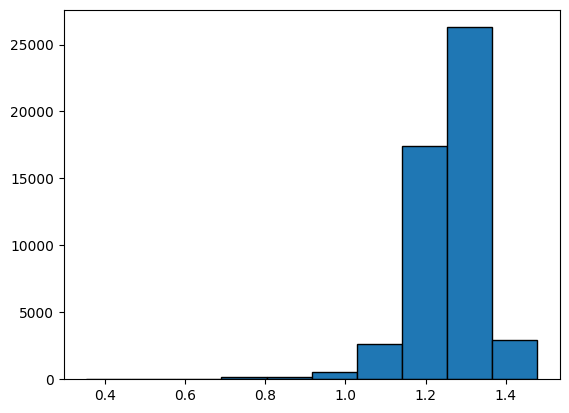

In [131]:
plt.hist(df["Distance"], edgecolor="black")